# ACCRE HPC Performance Analysis

## Project Overview

This project analyzes operational data from Vanderbilt University's Advanced Computing Center for Research and Education (ACCRE) High-Performance Computing (HPC) cluster to investigate factors associated with Slurm scheduler unresponsiveness.

Using large-scale Slurm job records together with scheduler log files from multiple compute gateways, the analysis evaluates whether bursts of completed jobs contribute to periods of reduced scheduler responsiveness. The project includes data exploration, preprocessing, feature engineering, exploratory data analysis, statistical modeling, and hypothesis testing to better understand scheduler performance under heavy workloads.

---

## Dataset Overview

The analysis integrates three operational datasets:

- **fullsample.csv** – Slurm job records containing job states, execution times, memory usage, CPU allocation, and completion status.
- **slurm_wrapper_ce5.log** – Scheduler command logs from the CE5 compute gateway.
- **slurm_wrapper_ce6.log** – Scheduler command logs from the CE6 compute gateway.

Scheduler unresponsive events were identified using operational criteria based on failed `sbatch` commands, return codes, and execution times, allowing statistical evaluation of scheduler behavior during periods of high system activity.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


**Phase 1: Explore the Data**

Objectives:

Understand the purpose of each dataset.
Inspect column types, sizes, and example rows.

In [ ]:
jobs = pd.read_csv("data/fullsample.csv")
jobs.head(5)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,PARTITION,EXITCODE
0,30616928,RUNNING,2021-07-31T22:15:00,Unknown,2048Mn,0,10:04:00,67-22:14:22,1,1,production,0:0
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1,1,cgw-platypus,0:0
2,30858137,COMPLETED,2021-08-06T19:04:39,2021-09-05T19:04:53,204800Mn,57553.77M,30-00:00:00,30-00:00:14,1,32,cgw-tbi01,0:0
3,30935078,COMPLETED,2021-08-09T16:52:51,2021-09-07T20:52:55,65536Mn,20577.96M,29-04:00:00,29-04:00:04,1,8,cgw-platypus,0:0
4,31364111_2,COMPLETED,2021-08-17T07:45:07,2021-09-10T16:45:24,16384Mn,9733.43M,24-09:00:00,24-09:00:17,1,1,production,0:0


In [ ]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395885 entries, 0 to 7395884
Data columns (total 12 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   JOBID      object
 1   STATE      object
 2   BEGIN      object
 3   END        object
 4   REQMEM     object
 5   USEDMEM    object
 6   REQTIME    object
 7   USEDTIME   object
 8   NODES      int64 
 9   CPUS       int64 
 10  PARTITION  object
 11  EXITCODE   object
dtypes: int64(2), object(10)
memory usage: 677.1+ MB


In [ ]:
print(jobs.columns)

Index(['JOBID', 'STATE', 'BEGIN', 'END', 'REQMEM', 'USEDMEM', 'REQTIME',
       'USEDTIME', 'NODES', 'CPUS', 'PARTITION', 'EXITCODE'],
      dtype='object')


In [ ]:
total_nan = jobs.isna().sum()
print(total_nan)

JOBID        0
STATE        0
BEGIN        0
END          0
REQMEM       0
USEDMEM      0
REQTIME      0
USEDTIME     0
NODES        0
CPUS         0
PARTITION    0
EXITCODE     0
dtype: int64


In [ ]:
ce5 = pd.read_csv("data/slurm_wrapper_ce5.log",
                  header=None,
                  delimiter=' - ',
                  engine='python')

ce5.rename(columns={
    0: "Date",
    1: "User",
    2: "Retry",
    3: "Time",
    4: "Returncode",
    5: "Command"
}, inplace=True)


In [ ]:
ce5.shape

(4770893, 6)

In [ ]:
ce5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4770893 entries, 0 to 4770892
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Date        object
 1   User        object
 2   Retry       object
 3   Time        object
 4   Returncode  object
 5   Command     object
dtypes: object(6)
memory usage: 218.4+ MB


* The ce5 data contains about 4.77M rows and 6 columns

In [ ]:
ce5.head()

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 08:15:39.278699,user 0,retry 0,time 0.07347559928894043,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
1,2020-10-16 08:18:08.313309,user 0,retry 0,time 0.18363237380981445,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
2,2020-10-16 08:22:48.128689,user 0,retry 0,time 0.07547116279602051,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
3,2020-10-16 08:25:13.257408,user 0,retry 0,time 0.09484362602233887,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
4,2020-10-16 08:31:01.460723,user 0,retry 0,time 0.07498788833618164,returncode 0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."


In [ ]:
ce6 = pd.read_csv("data/slurm_wrapper_ce6.log",
                  header=None,
                  delimiter=' - ',
                  engine='python')

ce6.rename(columns={
    0: "Date",
    1: "User",
    2: "Retry",
    3: "Time",
    4: "Returncode",
    5: "Command"
}, inplace=True)


In [ ]:
ce6.head(5)

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 10:37:44.163454,user 9202,retry 0,time 0.08495402336120605,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
1,2020-10-16 10:37:44.206654,user 9202,retry 0,time 0.08943057060241699,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
2,2020-10-16 10:37:44.218760,user 9202,retry 0,time 0.05928945541381836,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
3,2020-10-16 10:37:44.256403,user 9202,retry 0,time 0.038695573806762695,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."
4,2020-10-16 10:37:44.611603,user 9202,retry 0,time 0.03343677520751953,returncode 0,"command ['/usr/bin/scontrol', 'show', 'job', '..."


* The column names were changed from numerical to text format.
* Both the ce5 and ce6 data type contained mixed data types, such as numbers and text.

In [ ]:
combined_ce5_ce6 = pd.concat([ce5, ce6], ignore_index=True)


* Combined both cs5 and ce6 DataFrames.

In [ ]:
combined_ce5_ce6['User'] = (
    combined_ce5_ce6['User']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Retry'] = (
    combined_ce5_ce6['Retry']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Returncode'] = (
    combined_ce5_ce6['Returncode']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype("Int64")
)

combined_ce5_ce6['Time'] = (
    combined_ce5_ce6['Time']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
    .astype(float)
)

In [ ]:
combined_ce5_ce6.head(5)

,Date,User,Retry,Time,Returncode,Command
0,2020-10-16 08:15:39.278699,0,0,0.073476,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
1,2020-10-16 08:18:08.313309,0,0,0.183632,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
2,2020-10-16 08:22:48.128689,0,0,0.075471,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
3,2020-10-16 08:25:13.257408,0,0,0.094844,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."
4,2020-10-16 08:31:01.460723,0,0,0.074988,0,"command ['/usr/bin/sacct', '-u', 'appelte1', '..."


* The ce5 and ce6 DataFrames originally contained mixed data types, including numbers and text. These DataFrames were then combined and transformed into clean DataFrames.

**Phase 2: Clean and Transform the Data**

**Objectives:**

* Extract job completions from fullsample.csv.

* Parse CE5 and CE6 logs to identify unresponsive events.

**Rule:**
Unresponsive periods are indicated by "sbatch" commands from user 9204 that have:
return code = 1
execution time > 15 seconds

* Parse and clean the columns in the ce5 and ce6 DataFrames.
* Identify unresponsive events in both DataFrames.

In [ ]:
res_unres = combined_ce5_ce6[
    (combined_ce5_ce6['User'] == 9204) &
    (combined_ce5_ce6['Returncode'] == 1) &
    (combined_ce5_ce6['Time'] > 15) &
    (combined_ce5_ce6['Command'].str.contains("sbatch", case=False, na=False))
].copy()

print("Total unresponsive events:", len(res_unres))
print(res_unres.head())

Total unresponsive events: 3296
                             Date  User  Retry       Time  Returncode  \
49958  2020-10-18 06:53:44.272915  9204      0  20.038464           1   
49972  2020-10-18 06:54:04.322412  9204      1  20.048906           1   
50467  2020-10-18 07:47:25.825172  9204      0  20.082628           1   
50473  2020-10-18 07:47:45.871008  9204      1  20.045221           1   
50582  2020-10-18 07:53:33.972840  9204      0  20.041486           1   

                                                 Command  
49958  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
49972  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50467  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50473  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  
50582  command ['/usr/bin/sbatch', '/tmp/condor_g_scr...  


In [ ]:
res_unres = combined_ce5_ce6[
    (combined_ce5_ce6['User'] == 9204) &
    (combined_ce5_ce6['Command'].str.contains("sbatch", case=False, na=False))
].copy()

unresponsive = (res_unres['Returncode'] == 1) & (res_unres['Time'] > 15)

res_unres['Status'] = 'Responsive'
res_unres.loc[unresponsive, 'Status'] = 'Unresponsive'

print(res_unres['Status'].value_counts())

Status
Responsive      57951
Unresponsive     3296
Name: count, dtype: int64


* The number of unresponsive events was identified in the both ce5 and ce6 datasets.

* Extract job completions from fullsample.csv.

In [ ]:
jobs_completed = jobs[jobs['STATE'].str.contains('COMPLETED', na=False)].copy()
jobs_completed

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,PARTITION,EXITCODE
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1,1,cgw-platypus,0:0
2,30858137,COMPLETED,2021-08-06T19:04:39,2021-09-05T19:04:53,204800Mn,57553.77M,30-00:00:00,30-00:00:14,1,32,cgw-tbi01,0:0
3,30935078,COMPLETED,2021-08-09T16:52:51,2021-09-07T20:52:55,65536Mn,20577.96M,29-04:00:00,29-04:00:04,1,8,cgw-platypus,0:0
4,31364111_2,COMPLETED,2021-08-17T07:45:07,2021-09-10T16:45:24,16384Mn,9733.43M,24-09:00:00,24-09:00:17,1,1,production,0:0
5,31364111_3,COMPLETED,2021-08-17T07:45:07,2021-09-06T16:17:34,16384Mn,9708.04M,24-09:00:00,20-08:32:27,1,1,production,0:0
...,...,...,...,...,...,...,...,...,...,...,...,...
7395880,25493434,COMPLETED,2020-10-31T23:39:00,2020-10-31T23:40:46,2000Mn,0.09M,2-00:00:00,00:01:46,1,1,sam,0:0
7395881,25493435,COMPLETED,2020-10-31T23:39:13,2020-10-31T23:40:38,2000Mn,187.92M,2-00:00:00,00:01:25,1,1,sam,0:0
7395882,25493476,COMPLETED,2020-10-31T23:46:29,2020-10-31T23:49:43,4096Mc,803.97M,12:00:00,00:03:14,1,1,production,0:0
7395883,25493515,COMPLETED,2020-10-31T23:49:44,2020-10-31T23:51:40,2000Mn,0.09M,2-00:00:00,00:01:56,1,1,sam,0:0


**Create analysis-ready features (time windows, completion counts, unresponsiveness indicators).**

* Combined three datasets into a single DataFrame suitable for analysis.

In [ ]:
combined_data = pd.concat([jobs, res_unres], ignore_index=True).copy()
combined_data["Completed"] = (combined_data["STATE"] == "COMPLETED").astype(int)
combined_data["Running"] = (combined_data["STATE"] == "RUNNING").astype(int)
combined_data["Responsive"] = (combined_data["STATE"] == "RUNNING").astype(int)
combined_data["Unresponsive"] = (combined_data["Status"] == "Unresponsive").astype(int)

combined_data.head(2)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,...,User,Retry,Time,Returncode,Command,Status,Completed,Running,Responsive,Unresponsive
0,30616928,RUNNING,2021-07-31T22:15:00,Unknown,2048Mn,0,10:04:00,67-22:14:22,1.0,1.0,...,<NA>,<NA>,NaN,<NA>,NaN,NaN,0,1,1,0
1,30853133,COMPLETED,2021-08-06T11:36:09,2021-09-05T11:36:32,262144Mn,20604.62M,30-00:00:00,30-00:00:23,1.0,1.0,...,<NA>,<NA>,NaN,<NA>,NaN,NaN,1,0,0,0


* Jobs and unresponsive(res_unres) event logs were combined into a single dataset using a row-wise concatenation.* 

In [ ]:
combined_data["Date"] = pd.to_datetime(combined_data["Date"], format = "mixed", errors="coerce")
combined_data["BEGIN"] = pd.to_datetime(combined_data["BEGIN"], format = "mixed", errors="coerce")
combined_data["END"] = pd.to_datetime(combined_data["END"], format = "mixed", errors="coerce")

In [ ]:
combined_data[["Date", "BEGIN", "END"]].dtypes

Date     datetime64[ns]
BEGIN    datetime64[ns]
END      datetime64[ns]
dtype: object

In [ ]:
combined_data['Timestamp'] = (
    combined_data['END']
    .fillna(combined_data['BEGIN'])
    .fillna(combined_data['Date'])
)

combined_data['Timestamp'] = pd.to_datetime(
    combined_data['Timestamp'], format='mixed', errors='coerce')

combined_data = (combined_data.dropna(subset=['Timestamp'])
                .set_index(['Timestamp'])
                .sort_index()
)

for window in ['1min', '5min', '15min']: 
    combined_data[f'Completed_{window}'] = (
        combined_data['Completed']
        .rolling(window)
        .sum()
)
    
    combined_data[f'Running_{window}'] = (
        combined_data['Running']
        .rolling(window)
        .sum()
    )

    
    combined_data[f'Unresponsive_{window}'] = (
        combined_data['Unresponsive']
        .rolling(window)
        .sum()
    )
  

* To support time-based analysis, a unified `Timestamp` column was created by prioritizing job completion time (`END`), falling back to job start time (`BEGIN`), and finally to event time (`Date`).
All timestamp columns were explicitly converted to datetime format to ensure consistent time-window calculations.

In [ ]:
combined_data.head(5)

,JOBID,STATE,BEGIN,END,REQMEM,USEDMEM,REQTIME,USEDTIME,NODES,CPUS,...,Unresponsive,Completed_1min,Running_1min,Unresponsive_1min,Completed_5min,Running_5min,Unresponsive_5min,Completed_15min,Running_15min,Unresponsive_15min
Timestamp,,,,,,,,,,,,,,,,,,,,,
2020-10-01 00:10:15,24460577,COMPLETED,2020-10-01 00:05:55,2020-10-01 00:10:15,4096Mc,868.77M,12:00:00,00:04:20,1.0,1.0,...,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2020-10-01 00:12:58,24460647,COMPLETED,2020-10-01 00:10:38,2020-10-01 00:12:58,2000Mn,0.09M,2-00:00:00,00:02:20,1.0,1.0,...,0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0
2020-10-01 00:13:31,24460639,COMPLETED,2020-10-01 00:11:22,2020-10-01 00:13:31,1024Mc,221.10M,00:30:00,00:02:09,1.0,1.0,...,0,2.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0
2020-10-01 00:17:23,24460668,COMPLETED,2020-10-01 00:15:16,2020-10-01 00:17:23,2000Mn,0.09M,2-00:00:00,00:02:07,1.0,1.0,...,0,1.0,0.0,0.0,3.0,0.0,0.0,4.0,0.0,0.0
2020-10-01 00:17:53,24460671,COMPLETED,2020-10-01 00:17:08,2020-10-01 00:17:53,1024Mc,636.96M,00:30:00,00:00:45,1.0,1.0,...,0,2.0,0.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0


* Completion counts.

In [ ]:
print("Total completed jobs:", combined_data["Completed"].sum())
print("Total running jobs:", combined_data["Running"].sum())
print("Total unresponsive events:", combined_data["Unresponsive"].sum())

Total completed jobs: 7375084
Total running jobs: 208
Total unresponsive events: 3296


In [ ]:
combined_data["STATE"].value_counts().head()

STATE
COMPLETED            7375084
CANCELLED               9055
FAILED                  3766
CANCELLED by 9201       1776
OUT_OF_MEMORY           1739
Name: count, dtype: int64

In [ ]:
combined_data["Status"].value_counts().head()

Status
Responsive      57951
Unresponsive     3296
Name: count, dtype: int64

**Summary: Data preprocessing and transformation**

* Binary indicator variables were created to represent completed jobs(`STATE == "COMPLETED"`), running jobs (`STATE == "RUNNING"`), and unresponsive
events (`Status == "Unresponsive"`). Rolling time-window features (1, 5, and 15 minutes) were computed by summing these indicators, ensuring the features reflect
counts of completed jobs, running jobs, and unresponsive events.

* The resulting dataset is analysis-ready and is used for visualization and logistic regression modeling.


**Phase 3: Analyze and Visualize**

**Objectives:**

* Explore the relationship between job completions and unresponsiveness.
* Create visualizations and basic summary statistics.

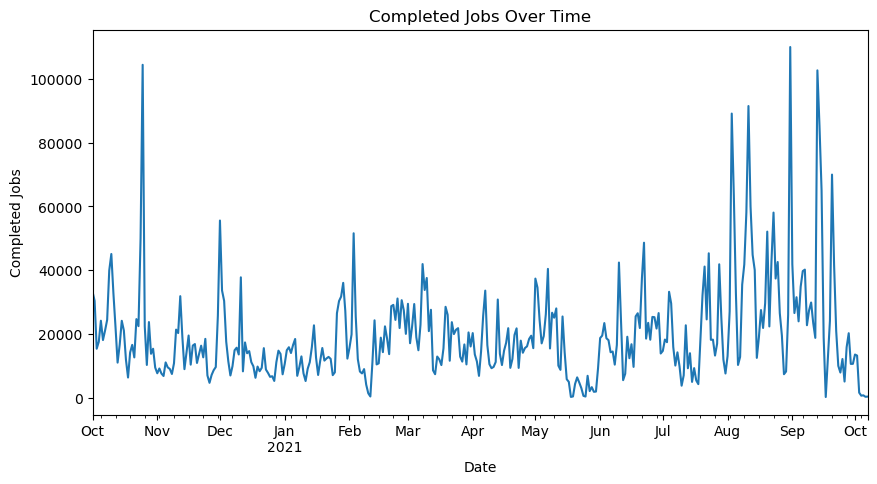

In [ ]:
events_over_time = (
    combined_data["Completed"]
    .resample("D")
    .sum()
)

events_over_time.plot(figsize=(10,5))
plt.title('Completed Jobs Over Time')
plt.xlabel('Date')
plt.ylabel('Completed Jobs')
plt.show()

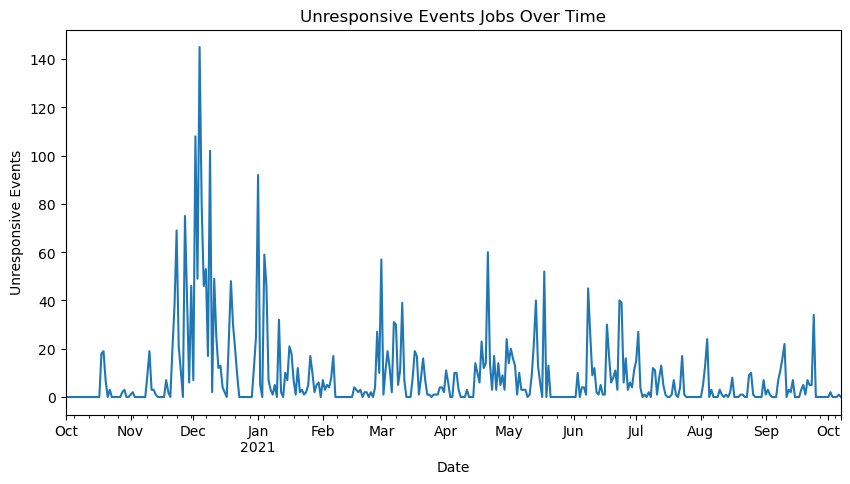

In [ ]:
events_over_time = (
    combined_data["Unresponsive"]
    .resample("D")
    .sum()
)

events_over_time.plot(figsize=(10,5))
plt.title('Unresponsive Events Jobs Over Time')
plt.xlabel('Date')
plt.ylabel('Unresponsive Events')
plt.show()

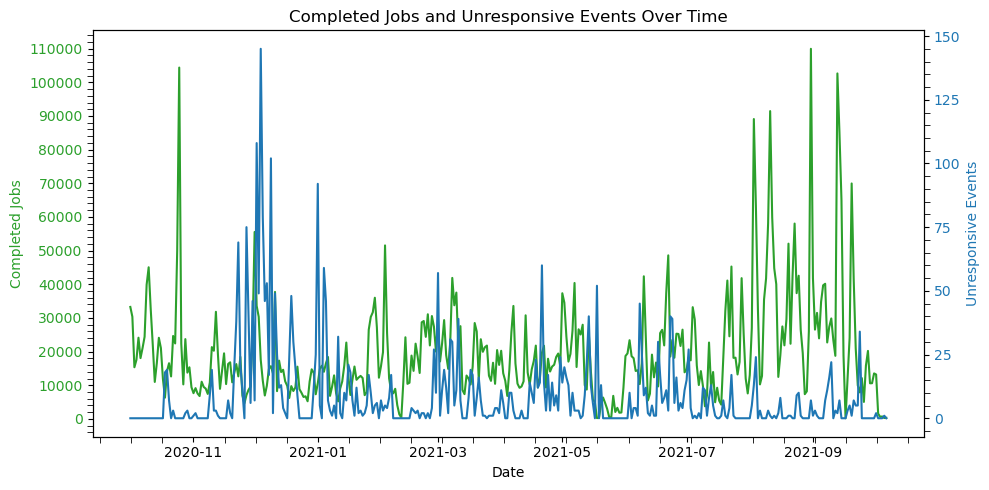

In [ ]:
Daily_Comple_Unres = combined_data.resample("D").agg({
    "Completed": "sum",
    "Unresponsive": "sum"
})
      
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    Daily_Comple_Unres.index,
    Daily_Comple_Unres["Completed"],
    color="tab:green"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Completed Jobs", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax1.set_yticks(
    np.arange(0, Daily_Comple_Unres["Completed"].max() + 10000, 10000)
)

ax1.minorticks_on()
ax1.tick_params(axis="both", which="minor", length=4)

ax2 = ax1.twinx()
ax2.plot(
    Daily_Comple_Unres.index,
    Daily_Comple_Unres["Unresponsive"],
    color="tab:blue"
)
ax2.set_ylabel("Unresponsive Events", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax2.set_yticks(
    np.arange(0, Daily_Comple_Unres["Unresponsive"].max() + 25, 25)
)
ax2.minorticks_on()
ax2.tick_params(axis="both", which="minor", length=4)

# Final touches
ax1.set_title("Completed Jobs and Unresponsive Events Over Time")
plt.tight_layout()
plt.show()


* Because completed job counts and unresponsive events differ substantially in scale, a secondary y-axis was used to visualize both series on a shared time axis.
* The time variable is stored as a DatetimeIndex (Timestamp), so the index is used as the x-axis when plotting time-series data.

* Distribution of Daily Job Events

In [ ]:
combined_data[["Completed", "Unresponsive"]].describe()

,Completed,Unresponsive
count,7.456689e+06,7.456689e+06
mean,9.890561e-01,4.420192e-04
std,1.040389e-01,2.101961e-02
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00
50%,1.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00


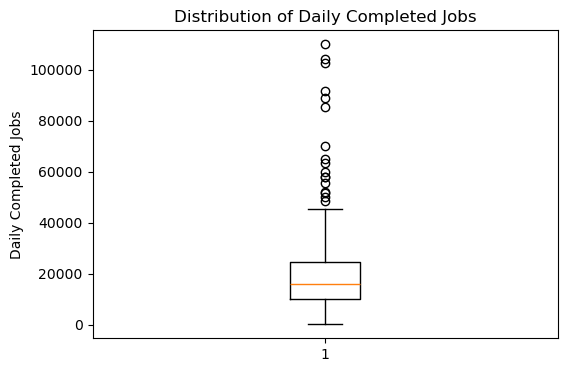

In [ ]:
daily_completed = combined_data["Completed"].resample('D').sum()

plt.figure(figsize=(6,4))
plt.boxplot(daily_completed, vert=True)
plt.ylabel('Daily Completed Jobs')
plt.title('Distribution of Daily Completed Jobs')
plt.show()

* The distribution of daily activity is right-skewed, with the mean exceeding the median and a longer upper whisker in the boxplot. This indicates that while most days exhibit
moderate activity levels, a small number of days experience substantially higher volumes, reflecting occasional workload surges.

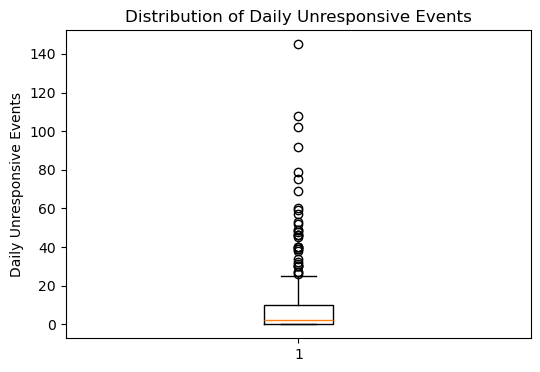

In [ ]:
daily_unresponsive = combined_data["Unresponsive"].resample('D').sum()

plt.figure(figsize=(6,4))
plt.boxplot(daily_unresponsive, vert=True)
plt.ylabel('Daily Unresponsive Events')
plt.title('Distribution of Daily Unresponsive Events')
plt.show()

* The distribution of daily unresponsive events is also right-skewed, with most days exhibiting few or no unresponsive events and a small number of days showing elevated
counts. In addition, the distribution reflects rare but notable spikes in activity.

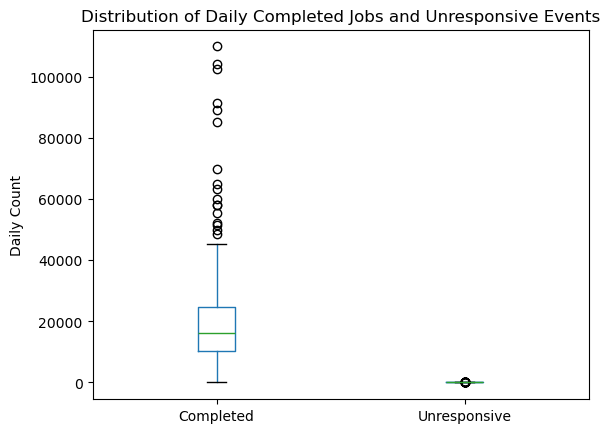

In [ ]:
Daily_Comple_Unres_bx = combined_data.resample("D").agg({
    "Completed": "sum",
    "Unresponsive": "sum"
}).reset_index()


Daily_Comple_Unres_bx[["Completed", "Unresponsive"]].boxplot(grid=False, vert=True)
plt.title("Distribution of Daily Completed Jobs and Unresponsive Events")
plt.suptitle('')
plt.ylabel('Daily Count')
plt.show()

* Despite the large difference in scale, both distributions exhibit right-skewed behavior, suggesting that periods of unusually high system activity may coincide
with increased occurrences of unresponsive events.

**Summary for the section of plots and statistics:** 
* The visualizations show substantial variability in system activity over time, with job completions exhibiting a right-skewed distribution characterized by occasional
high-throughput periods. Unresponsive events are comparatively rare but also display right-skewed behavior, with most days showing few or no events and occasional spikes.
Despite the large difference in scale, the temporal patterns suggest that periods of elevated job completion activity may coincide with increased unresponsiveness. These
observations motivate the use of logistic regression to formally assess this relationship.

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

* Fit a simple logistic regression to test the hypothesis.

In [ ]:
stats_model_df = combined_data[combined_data['Status'].isin(['Responsive', 'Unresponsive'])].copy()

stats_model_df['Unresponsive'] = (stats_model_df['Status'] == 'Unresponsive').astype(int)

unresp_comple_logreg = smf.logit(
    "Unresponsive ~ Completed_5min",
    data=stats_model_df.dropna(subset=['Unresponsive', 'Completed_5min'])
).fit()


Optimization terminated successfully.
         Current function value: 0.209224
         Iterations 7


In [ ]:
print(unresp_comple_logreg.summary())

                           Logit Regression Results                           
Dep. Variable:           Unresponsive   No. Observations:                61247
Model:                          Logit   Df Residuals:                    61245
Method:                           MLE   Df Model:                            1
Date:                Tue, 06 Jan 2026   Pseudo R-squ.:                0.001785
Time:                        16:16:13   Log-Likelihood:                -12814.
converged:                       True   LL-Null:                       -12837.
Covariance Type:            nonrobust   LLR p-value:                 1.288e-11
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.7940      0.021   -133.293      0.000      -2.835      -2.753
Completed_5min    -0.0012      0.000     -6.067      0.000      -0.002      -0.001


In [ ]:
unresp_comple_logreg.params

Intercept        -2.794045
Completed_5min   -0.001244
dtype: float64

In [ ]:
odds_ratio = np.exp(-0.0012)
percent_increase = (odds_ratio - 1) * 100
print(f"Odds ratio: {odds_ratio:.2f}")
print(f"Percent increase in odds: {percent_increase:.1f}%")

Odds ratio: 1.00
Percent increase in odds: -0.1%


In [ ]:
odds_ratio_100 = np.exp((-0.0012)*100)
percent_increase_100 = (odds_ratio_100 - 1) * 100
print(f"Odds ratio(100 jobs): {odds_ratio_100:.2f}")
print(f"Percent increase in odds(100): {percent_increase_100:.1f}%")

Odds ratio(100 jobs): 0.89
Percent increase in odds(100): -11.3%


* Exponentiating the coefficients an odds ratio rounds to 1.00 per additional completed job in the prior 5 minutes, corresponding to a 0.1% decrease
in the odds of unresponsiveness per job. While the per-job effect is small, a 100-job increase in recent completions is associated with an approximately 11.3% reduction in the odds of unresponsiveness.

In [ ]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
events_value = 100
logit_p = (
    unresp_comple_logreg.params['Intercept'] 
    + unresp_comple_logreg.params['Completed_5min']*events_value
)
print(f"Jobs Completed in 5minutes = {events_value} ->"
f" Estimated Probability of Slurm Scheduler Unresponsiveness in 5 minutes: {logistic(logit_p):.4f}")

Jobs Completed in 5minutes = 100 -> Estimated Probability of Slurm Scheduler Unresponsiveness in 5 minutes: 0.0512


In [ ]:
for X in [0, 50, 100, 200, 300, 500]:
    logit_p = (
        unresp_comple_logreg.params["Intercept"]
        + unresp_comple_logreg.params["Completed_5min"] * X
    )
    print(f"{X:>3} Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = {logistic(logit_p):.4f}")

  0 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0576
 50 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0544
100 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0512
200 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0455
300 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0404
500 Completed jobs -> Estimated Probability of Slurm Scheduler Unresponsiveness = 0.0318


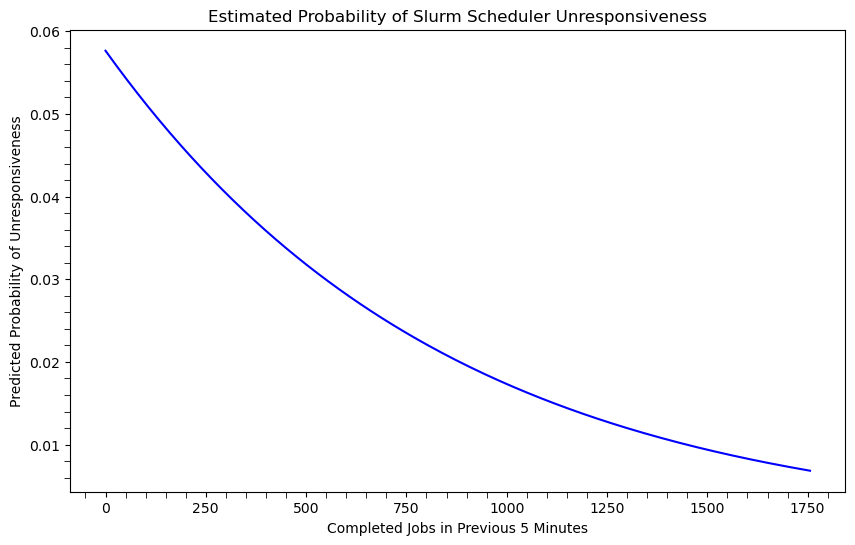

In [ ]:
fit_df = pd.DataFrame({
    'Completed_5min': np.linspace(start = stats_model_df['Completed_5min'].min(),
                            stop = stats_model_df['Completed_5min'].max(),
                            num = 200)
})

fit_df['fit'] = unresp_comple_logreg.predict(fit_df)

fit_df.plot(x = 'Completed_5min',
             y = 'fit',
             legend = False,
             figsize = (10,6),
             color = 'blue')
plt.minorticks_on()
plt.tick_params(axis="both", which="minor", length=4)
plt.title('Estimated Probability of Slurm Scheduler Unresponsiveness')
plt.ylabel('Predicted Probability of Unresponsiveness')
plt.xlabel('Completed Jobs in Previous 5 Minutes')
plt.show()

* The figure shows the fitted values from a logistic regression model estimating the probability of scheduler unresponsiveness as a function of the number of completed
jobs in the previous 5 minutes (`Completed_5min`). Predicted probabilities were generated by evaluating the fitted model across a range of observed (Completed_5min) values and plotting the resulting probabilities against the
predictor.

* The x-axis represents the number of completed jobs in the prior 5-minute window, and the y-axis represents the model-predicted probability of an unresponsive event.

**Phase 4: Interpret and Conclude**

**Objectives:**

**Answer the main question:** Does the data support the hypothesis that the slurm scheduler is more likely to be unresponsive during bursts of job completions?
Summarize findings and limitations.

**No.** 
* After refitting the logistic regression model using the correct predictor (Completed_5min), the results do not support the original hypothesis. The estimated
coefficient on Completed_5min is negative and statistically significant, indicating that higher numbers of completed jobs in the preceding 5-minute window are associated
with a lower probability of scheduler unresponsiveness.This suggests that periods of high job completion throughput correspond to smoother scheduler operation rather than increased instability. One plausible interpretation is that high completion rates reflect healthy system performance, whereas unresponsive events are more likely during periods of congestion or reduced throughput.

**Findings:**
* Using a logistic regression model with the correct predictor (Completed_5min), the analysis finds a statistically significant negative association between recent job
completions and scheduler unresponsiveness. Specifically, higher numbers of completed jobs in the preceding 5-minute window are associated with lower odds of unresponsive
events. Predicted probabilities decrease as recent completion throughput increases, indicating that periods of high job completion activity correspond to more stable
scheduler behavior rather than elevated risk.

**Limitations:**
* Several limitations should be noted. The analysis is observational and cannot establish causality, unresponsive events are relatively rare, and completed-job counts may not
fully capture all aspects of system load (e.g., queued or stalled jobs). Nevertheless, the corrected model directly addresses the research question and indicates that bursts
of job completions are not associated with increased scheduler unresponsiveness.


**Notebook Sections:**

**Summarize evidence for or against the hypothesis.**

* The hypothesis proposes that the Slurm scheduler is more likely to be unresponsive during bursts of job completions. Exploratory analysis shows that job completion activity varies
over time, with most periods exhibiting moderate throughput and occasional short-term bursts. However, after refitting the logistic regression model using the correct measure
of short-term activity (Completed_5min), the results do not support the hypothesis.

* The estimated coefficient on Completed_5min is negative and statistically significant, indicating that higher numbers of completed jobs in the preceding five-minute window are
associated with a lower probability of scheduler unresponsiveness. Predicted probabilities from the model decrease as recent job completion throughput increases,
suggesting that periods of high completion activity correspond to smoother scheduler operation rather than increased instability.

**Conclusion**
* Overall, the results do not support the hypothesis that the Slurm scheduler is more likely to be unresponsive during bursts of job completions. After refitting the logistic regression model using the correct predictor (Completed_5min), higher short-term job completion volume is associated with a lower probability of scheduler unresponsiveness. Although unresponsive events are relatively rare, the analysis suggests that periods of
high job completion throughput correspond to smoother scheduler operation rather than increased instability. This analysis is observational and does not establish causality, but it provides evidence that bursts of completed jobs are not linked to increased scheduler unresponsiveness.